Analyzing the results of the full run of find_SARFI_multi.py on the 1in25 dataset

### Setup

In [1]:
# Import regular packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import itertools
from datetime import datetime
from astropy.time import Time
import os
import ast

In [2]:
# Load in data
data_dir = "/mnt/cosmic-gpu-1/data0/nstiegle/representative_samples/"
filename = "1in25_good_targets_results_cleaned.pkl"
data_file = data_dir + filename
df = pd.read_pickle(data_file)

# used to load in the csv, but now we're using the pickle file because
# it loads in the numpy arrays correctly, whereas the csv had them as strings
# df = pd.read_csv(data_file)
# df = df.drop(df.columns[0], axis='columns') # Picked up extra index column. Remove it
# df = df.drop(df.columns[0], axis='columns') # Picked up 2 extra index columns


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/cosmic-gpu-1/data0/nstiegle/representative_samples/1in25_good_targets_results_cleaned.pkl'

In [ ]:
# # Script got messed up and some of the lists got saved as strings, so try to recover those
# df["antenna_titles"] = np.array([ast.literal_eval(stringed_array) for stringed_array in df["antenna_titles"]], dtype='object')
# df["antenna_snrs"] = np.array([np.fromstring((stringed_array.strip('[]')), sep=' ', dtype=float) for stringed_array in df["antenna_snrs"]], dtype='object')
# df["antenna_signals"] = np.array([np.fromstring((stringed_array.strip('[]')), sep=' ', dtype=float) for stringed_array in df["antenna_signals"]], dtype='object')

In [ ]:
# Save new df as a pickle file (so it can load the numpy arrays)
# df.reset_index(drop=True).to_pickle(data_dir + "1in25_good_targets_results_cleaned.pkl")

In [ ]:
# Make sure we can load in the data from the pickle file
# df2 = pd.read_pickle(data_dir + "1in25_good_targets_results_cleaned.pkl")

In [ ]:
groups = df.groupby('source_name')
group_names = list(groups.groups.keys())
group_sizes = list(groups.size())
print(group_names)
print(group_sizes)
print(sum(group_sizes), "total hits")

['2535280716217508992', '2536546185381558272', '2542485953354555264', '2557518579407455104', '2646431411821304960', '3073619025268414208', '3074407546904630144', '3079227054261900160', '3113482167231459200', '3113490855946843904', '3113491272562268160', '3113493127988068096', '3127348761205770496', 'Incoherent', 'PHASE_CENTER']
[2074, 3519, 14978, 2654, 78692, 6335, 4558, 3088, 207, 193, 214, 193, 2775, 255942, 868803]
1244225 total hits


In [ ]:
print(len(groups.groups.keys()))
print("Makes sense that we have 13 named sources + the incoherent & phase_center data for 15 total")

15
Makes sense that we have 13 named sources + the incoherent & phase_center data for 15 total


In [ ]:
# i = 0
# group = groups.get_group(group_names[0])
# for snrs in group["antenna_snrs"]:
#     # Normalize powers of all antennas ()

Revisiting this on 3/7/26. Not sure what I was doing, but hoping to characterize the SARFI for the VLASS paper

In [ ]:
# Let's get rid of the INCOHERENT?

In [ ]:
# Look into what we're looking at here
group = groups.get_group(group_names[0])
print(group.shape)
print(group.columns)

In [ ]:
# group.iloc[:10][["telescope_id", "antenna_titles", "antenna_snrs", "antenna_signals"]]

In [ ]:
df.iloc[0]["antenna_snrs"]

In [ ]:
# Quick and dirty way to tell if a row is SARFI
# The row has the signals from the antennas corresponding to a single hit
# where the signals have the intensities in the drift line for the hit
# from each antenna
def max_to_sum_score(signals):
    # Calculate the distribution of energy in each signal
    total = sum(signals)
    signal_distribution = [signal / total for signal in signals]

    return max(signal_distribution)

# Calculate the gini coefficient for a given set of antenna signals
# for a given stamp
def gini_score(signals):
    
    ### From gemini
    # Mean absolute difference
    mad = np.abs(np.subtract.outer(signals, signals)).mean() # Makes an nxn matrix, so don't use if there are >100 antennas
    # Relative mean absolute difference
    rmad = mad / np.mean(signals)
    # Gini coefficient
    return 0.5 * rmad


In [ ]:
# test the gini score from gemini
# assert(gini_score([10, 10, 10]) == 0)
# assert(gini_score([10000, 0, 0, 0, 0, 0, 0, 0, 0, 0]) > 0.5)
# gini_score([5000, 5000, 0, 0, 0, 0, 0, 0, 0, 0])


0.5

In [ ]:
# Calculate the max-to-sum and gini score for all rows of the dataframe
df["max_to_sum_score"] = df["antenna_signals"].apply(max_to_sum_score)
df["gini_score"] = df["antenna_signals"].apply(gini_score)

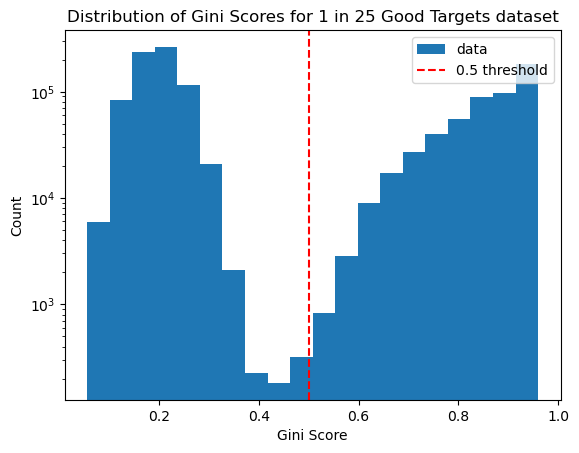

In [ ]:
# Look at distribution of gini scores
plt.hist(df["gini_score"], bins=20, label="data")
gini_threshold = 0.5
plt.axvline(x=gini_threshold, color='r', linestyle='--', label=f"{gini_threshold} threshold")

plt.xlabel("Gini Score")
plt.ylabel("Count")
plt.title("Distribution of Gini Scores for 1 in 25 Good Targets dataset")
plt.legend()
plt.yscale('log')
plt.show()

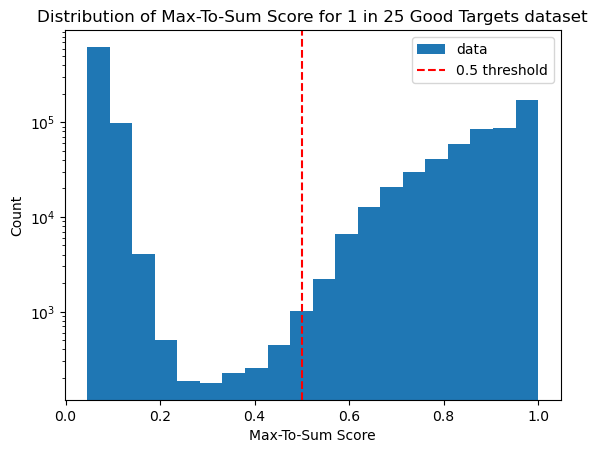

In [ ]:
# Look at distribution of gini scores
plt.hist(df["max_to_sum_score"], bins=20, label="data")
mts_threshold = 0.5
plt.axvline(x=mts_threshold, color='r', linestyle='--', label=f"{mts_threshold} threshold")

plt.xlabel("Max-To-Sum Score")
plt.ylabel("Count")
plt.title("Distribution of Max-To-Sum Score for 1 in 25 Good Targets dataset")
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
# Define populations that get cut by the thresholds
hits_over_gini_threshold = df["gini_score"] > gini_threshold
hits_over_mts_threshold = df["max_to_sum_score"] > mts_threshold

# Get number statistics
gini_over_threshold = sum(hits_over_gini_threshold)
mts_over_threshold = sum(hits_over_mts_threshold)
total_hits = len(df)

# Print number statistics
print(gini_over_threshold, "hits above the Gini threshold out of ", total_hits, "hits total", round(gini_over_threshold / total_hits * 100, 3), "%")
print(mts_over_threshold, "hits above the Max-To-Sum threshold out of ", total_hits, "hits total", round(mts_over_threshold / total_hits * 100, 3), "%")

# compare populations
print()
total_cut = (hits_over_gini_threshold | hits_over_mts_threshold).sum()
print(total_cut, "Hits over one or the other threshold")
both_cut = (hits_over_gini_threshold & hits_over_mts_threshold).sum()
print(both_cut, "hits above both thresholds", both_cut / total_cut * 100, "% of hits above either threshold")
gini_cut = (hits_over_gini_threshold & ~hits_over_mts_threshold).sum()
print(gini_cut, "hits above Gini threshold only", gini_cut / total_cut * 100, "% of hits above gini threshold only")
mts_cut = (~hits_over_gini_threshold & hits_over_mts_threshold).sum()
print(mts_cut, "hits above Max-To-Sum threshold only", mts_cut / total_cut * 100, "% of hits above max-to-sum threshold only")

# Discussion
print()
print("this makes sense because the max-to-sum score is set more conservatively to match current implementation")
print("It looks good that both scores are so similar")

516188 hits above the Gini threshold out of  1244225 hits total 41.487 %
515362 hits above the Max-To-Sum threshold out of  1244225 hits total 41.42 %

516190 Hits over one or the other threshold
515360 hits above both thresholds 99.83920649373292 % of hits above either threshold
828 hits above Gini threshold only 0.16040605203510336 % of hits above gini threshold only
2 hits above Max-To-Sum threshold only 0.00038745423196884866 % of hits above max-to-sum threshold only

this makes sense because the max-to-sum score is set more conservatively to match current implementation
It looks good that both scores are so similar


In [ ]:
# Let's use the Gini score because it's more robust and we're doing post-processing
# so real-time constraints aren't as much of an issue
SARFI_hits = df[hits_over_gini_threshold]

# We're also only going to look at the incoherent hits, because we don't
# want to double count the same hit in the coherent and incoherent data
SARFI_hits = SARFI_hits[SARFI_hits["source_name"] == "Incoherent"]
assert(SARFI_hits["source_name"].nunique() == 1 and SARFI_hits["source_name"].unique()[0] == "Incoherent")

In [ ]:
# Let's look at the antennas which have the most SARFI

# Define a function to find those signals
# Given a list of signals, returns the indices of the signals in the array
# which have the most signal (works for SARFI signals, after the check for gini
# inequality)
def indices_with_most_signal(signals):
    idx = np.argsort(signals)[::-1] # Sort in descending order
    norm_and_sorted_signals = signals[idx] / sum(signals)
    signal_drops = np.abs(np.diff(norm_and_sorted_signals))

    # Look for the largest drop in signal, and return the indices of the signals above that drop
    largest_drop_idx = np.argmax(signal_drops)
    return idx[:largest_drop_idx + 1]

# Test
a = np.array([1, 2, 8, 3, 7, 1, 2, 1, 1, 0])
indices = indices_with_most_signal(a)
print(a)
print(a[indices])

[1 2 8 3 7 1 2 1 1 0]
[8 7]
